# Root to Tip Plot from TempEst, Exported to Python

Goals:
* Time vs. genetic distance
* Color by state
* Shape by host

In [1]:
# Housekeeping

import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt
from matplotlib import pyplot

downloads = "C:/Users/maksi/Documents/Statistics/Projects/Avian_Flu_Files/"
# downloads = "C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/"
cat_files = downloads + "Cats/"



                                                    tip         date  \
0     A/Alpaca/ID/24-015080-001-original/2024|H5N1|U...  2024.382514   
1     A/cattle/ID/24-017916-002/2024|H5N1|USA-ID|202...  2024.448087   
2     A/cattle/ID/24-017916-001/2024|H5N1|USA-ID|202...  2024.448087   
3     A/Cattle/ID/24-015674-002/2024|H5N1|USA-ID|202...  2024.393443   
4     A/cattle/Idaho/24-015674-002-R2/2024|H5N1|USA-...  2024.393443   
...                                                 ...          ...   
2503  A/rock_pigeon/UT/24-032856-014/2024|H5N1|USA-U...  2024.827869   
2504  A/chicken/UT/24-030010-001/2024|H5N1|USA-UT|20...  2024.775956   
2505  A/rock_pigeon/UT/24-032857-004/2024|H5N1|USA-U...  2024.825137   
2506  A/chicken/UT/24-030010-002/2024|H5N1|USA-UT|20...  2024.775956   
2507  A/MOUNTAIN_LION/NV/24-038822-001/2024|H5N1|USA...  2024.939891   

      distance  residual   state Abbreviation     host_type           host  \
0     0.000384 -0.001181  USA-ID           ID  other_mamm

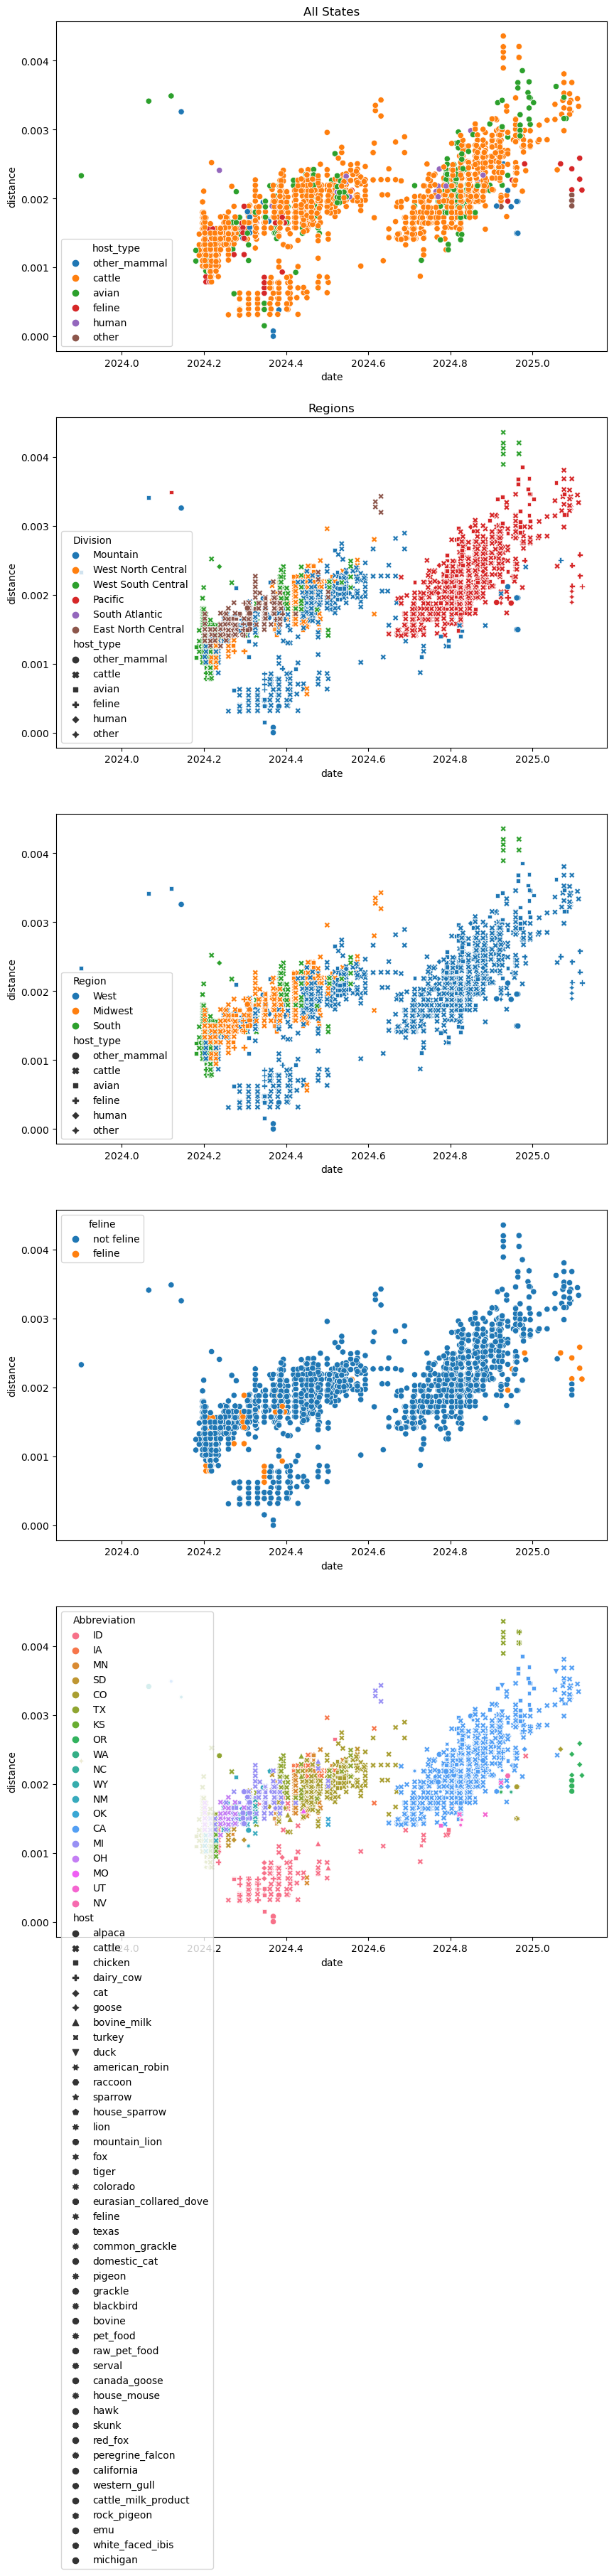

In [6]:
os.chdir(downloads)

states = pd.read_csv("states_ref.csv")

os.chdir(cat_files)

df = pd.read_csv("B3_13_APR14_tempest_r2t_feline.txt", delimiter="\t")

df["state"] = df["tip"].apply(lambda x: x.split("|")[2])
df["Abbreviation"] = df["tip"].apply(lambda x: x.split("|")[2][4:])
df["host_type"] = df["tip"].apply(lambda x: x.split("|")[4])
df["host"] = df["tip"].apply(lambda x: x.split("/")[1].lower().replace(" ", "_").replace("'", "").replace("-","_"))
df["feline"] = df["host_type"].apply(lambda x: "feline" if x == "feline" else "not feline")

df_states = df.merge(states, on="Abbreviation")

df_states_copy = df_states

print(df_states)

df_felines = df_states[df_states["host_type"] == "feline"]

print(df_felines)

fig, axes = pyplot.subplots(5, 1, figsize = (10, 35))
sns.scatterplot(ax=axes[0], data=df_states, x="date", y="distance", hue="host_type") #, style="") # All states
sns.scatterplot(ax=axes[1], data=df_states, x="date", y="distance", hue="Division", style="host_type") # State divisions
sns.scatterplot(ax=axes[2], data=df_states, x="date", y="distance", hue="Region", style="host_type") # USA Regions
sns.scatterplot(ax=axes[3], data=df_states, x="date", y="distance", hue="feline") #, style="host") # Cats only
sns.scatterplot(ax=axes[4], data=df_states, x="date", y="distance", hue="Abbreviation", style="host")

# fig.suptitle("B3.13 Complete Dates Root-to-Tip Plots Updated April 14")
axes[0].set_title("All States")
axes[1].set_title("Regions")

fig.savefig("B3_13_APR14_r2t_feline.png")


In [3]:
# # Create tsv with color annotations for host_type

# # print(df_states)

# colors = {"avian": ["#fcffa4"], "cattle": ["#fca50a"], "human": ["#dd513a"], "feline": ["#932667"], "other_mammal": ["#420a68"], "other": ["#000004"]}

# color_df = pd.DataFrame.from_dict(colors).T

# color_df["host_type"] = color_df.index
# color_df["color"] = color_df[0]
# color_df = color_df.reset_index()
# color_df = color_df[["host_type", "color"]]

# # print(color_df)

# df_states_color = df_states.merge(color_df, on="host_type")

# print(df_states_color)

# df_states_color[["tip", "host_type"]].to_csv("B3_13_APR14_annotations.tsv", sep="\t", index=False)

In [4]:
# os.chdir(cat_files)

# df = pd.read_csv("B3_13_APR14_complete_dates_relabeled_felines.csv")

# df["state"] = df["full_header"].apply(lambda x: x.split("|")[2])
# df["Abbreviation"] = df["full_header"].apply(lambda x: x.split("|")[2][4:])
# df["host_type"] = df["full_header"].apply(lambda x: x.split("|")[4])
# df["host"] = df["full_header"].apply(lambda x: x.split("/")[1].lower().replace(" ", "_").replace("'", "").replace("-","_"))
# df["feline"] = df["host_type"].apply(lambda x: "feline" if x == "feline" else "not feline")

# df_states = df.merge(states, on="Abbreviation")

# print(df_states)

In [5]:
# df_states["tip"] = df_states["full_header"].apply(lambda x: x[1:])
# df_states.loc[df_states["host"] == "bovine_milk", 'host_type'] = "cattle"
# df_states = df_states.rename(columns={"host_type":"host_type_feline"})

# print(df_states)
# print(df_states_copy)

# annotations_feline_pre = df_states.merge(df_states_copy, on="tip")

# annotations_feline = df_states[["tip", "host_type_feline"]]

# print(annotations_feline)

# annotations_feline.to_csv("feline_annotations.tsv", sep="\t", index=False)